# Replicating GEOCOURT: Mapping Legal Integration in the EU

This notebook replicates the two main cartographic exhibits in Dyevre, A. and Lampach, N., *"Subnational Disparities in EU Law Use: Exploring the GEOCOURT Dataset"*, using the GEOCOURT dataset (courts submitting Article 267 preliminary references to the Court of Justice of the European Union, 1961–2017) together with Eurostat NUTS2 (2013) boundary data.

Three figures are produced:

1. **Figure 1** — location of every referring court, coloured by court tier (peak vs. non-peak) and sized by referral volume.
2. **Figure 2** — a NUTS2-level choropleth of regional referral intensity.
3. **Figure A2** — Figure 1 broken down into three sub-periods (1961–1985, 1986–2003, 2004–2017), replicating the paper's own periodised appendix figure.

## Data

- `GEOCOURT_NUTS_2.csv` — court-level dataset: one row per preliminary reference, including the referring court's identifier, coordinates, NUTS2 region, peak-court status and year of referral.
- `NUTS_RG_20M_2013_3035.gpkg` — Eurostat NUTS2 (2013 vintage) region boundaries, used as the cartographic basemap and matching the paper's own coverage period.

## 1. Setup

Constants defined here are shared across all three figures: the set of EU member states in scope, the NUTS2013 codes for overseas/outermost regions to be excluded from the map, and the colour and size encoding used consistently throughout.

In [14]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import Point
import textwrap

In [15]:
EU28 = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI',
       'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL',
       'PT', 'RO', 'SE', 'SI', 'SK', 'UK']

# Outermost / overseas NUTS2 regions (NUTS2013 codes), excluded from the basemap so that
# a handful of small, distant territories do not force the map's extent to include the
# mid-Atlantic, the Caribbean or North Africa.
EXCLUDED_NUTS_IDS = [
    'FRA1', 'FRA2', 'FRA3', 'FRA4', 'FRA5',   # French overseas departments
    'ES63', 'ES64',                            # Ceuta and Melilla
    'ES70',                                    # Canary Islands
    'PT20', 'PT30',                            # Azores and Madeira
]

# Colour and size encoding shared by Figure 1 and Figure A2
COURT_COLORS = {'First Instance': '#4C9F70', 'Second Instance': '#E8A33D', 'Peak Court': '#D6483F'}
COURT_LABELS = {'First Instance': 'First Instance', 'Second Instance': 'Second Instance (Court of Appeal)', 'Peak Court': 'Peak Court'}
COURT_TIER_ORDER = ['First Instance', 'Second Instance', 'Peak Court']

# Referral-volume tiers matching the paper's own Figure 1 legend (25 / 50 / 75 / 100).
FREQ_BINS = [0, 25, 50, 75, np.inf]
FREQ_LABELS = ['1–25', '26–50', '51–75', '76+']
SIZE_MAP = {'1–25': 90, '26–50': 160, '51–75': 240, '76+': 340}

## 2. Data

### 2.1 Court-level referral data

Latitude and longitude are stored as strings in the raw file and are coerced to numeric before building any geometry.

One court required a manual correction: `court_ID = 'ES0560A'` (Juzgado de Primera Instancia, Palma) is geocoded to the Canary Islands (`Nuts2 = 'ES70'`), despite its own `City` field reading *"Palma (Islas Baleares)"* and a same-city sibling court (Audiencia Provincial, Palma) being correctly coded to the Balearic Islands (`ES53`). The coordinates are corrected to the sibling court's location rather than dropping the observation, since it is a genuine mainland court and not an outermost-region case.

In [16]:
courts_raw = pd.read_csv('GEOCOURT_NUTS_2.csv', sep=';', engine='python', encoding='latin-1', on_bad_lines='skip')
courts_raw['Latitude'] = pd.to_numeric(courts_raw['Latitude'], errors='coerce')
courts_raw['Longitude'] = pd.to_numeric(courts_raw['Longitude'], errors='coerce')
courts_raw = courts_raw.dropna(subset=['Latitude', 'Longitude', 'court_ID'])

# Palma de Mallorca / Canary Islands mis-geocoding
palma_mask = courts_raw['court_ID'] == 'ES0560A'
courts_raw.loc[palma_mask, 'Nuts2'] = 'ES53'
courts_raw.loc[palma_mask, 'Latitude'] = 39.569582
courts_raw.loc[palma_mask, 'Longitude'] = 2.650075

### 2.2 Basemap

The basemap is restricted to the EU28 and to mainland/contiguous territory: NUTS2013's outermost regions (French overseas departments, Ceuta and Melilla, the Canary Islands, the Azores and Madeira) are excluded so that the map's bounding box reflects the continental EU rather than being stretched across three oceans.

In [17]:
nuts2_gdf = gpd.read_file('NUTS_RG_20M_2013_3035.gpkg')
nuts2_gdf = nuts2_gdf[nuts2_gdf['LEVL_CODE'] == 2]
nuts2_gdf = nuts2_gdf[nuts2_gdf['CNTR_CODE'].isin(EU28)]
nuts2_gdf = nuts2_gdf[~nuts2_gdf['NUTS_ID'].isin(EXCLUDED_NUTS_IDS)]

VALID_NUTS_IDS = set(nuts2_gdf['NUTS_ID'])
print(courts_raw.shape)
print(courts_raw.columns.tolist())

(10741, 30)
['ref_id', 'ref_outcome', 'order_type', 'date_submit', 'date_end', 'country', 'ref_year', 'ref_no', 'court_name_old', 'court_code', 'court_name_future', 'court_name_match', 'court_ID', 'Levenshtein', 'CLX_CJ', 'CLX_CO', 'CLX_CC', 'joined_court', 'joined_AG', 'party_1', 'party_2', 'status', 'peak_court', 'City', 'Latitude', 'Longitude', 'CNTR_CODE', 'Nuts2', 'Court', 'int_court']


### 2.3 Building a reusable court-level table

Court names are recorded inconsistently across the sample period — 1,148 unique name strings correspond to only 1,664 unique court identifiers — so all aggregation below is performed on `court_ID` rather than on the `Court` name field.

Two helper functions are defined here and reused by both Figure 1 and Figure A2:

- `build_static_court_table` collapses the referral-level data to one row per court, carrying forward attributes that do not vary over time (location, peak-court status).
- `build_court_geodataframe` aggregates referral frequency for a given date range (or the full sample, if no range is given), assigns each court to a size tier, and returns a ready-to-plot `GeoDataFrame`. Figure 1 calls this once for the full 1961–2017 period; Figure A2 calls it once per sub-period.

On the peak-court tier itself: the released GEOCOURT_NUTS_2.csv encodes a referring court's position in the domestic hierarchy using two separate binary flags, peak_court and int_court, rather than a single ordinal tier variable. Cross-tabulating the two reveals 157 rows flagged as both peak_court=1 and int_court=1 simultaneously. This combination should not exist under a strictly hierarchical reading. Inspecting the court names behind these rows shows they are not data errors: they correspond to 8 distinct courts falling into two explainable categories — UK/Scottish courts (e.g. the Court of Appeal of England and Wales, the Court of Session), whose structure does not map cleanly onto a single continental-style hierarchy, and "administrative supreme courts" (Luxembourg, Vilnius, Warsaw, Lisbon), which sit at the apex of the administrative-law track specifically but below a general supreme or constitutional court overall. These courts are given `court_tier = 'Peak Court'` whenever `peak_court == 1`, regardless of `int_court`, since the paper's footnote 4 defines peak-court status institutionally (supreme or constitutional court) rather than by which specific proceeding produced a given reference; that institutional definition does not change simply because a case also carries an intermediate flag.

In [18]:
def build_static_court_table(df):
    """One row per unique court, carrying forward attributes that do not
    vary by referral or by time period (location, peak-court status)."""
    table = df.groupby('court_ID').agg(
        Court=('Court', 'first'),
        Latitude=('Latitude', 'first'),
        Longitude=('Longitude', 'first'),
        CNTR_CODE=('CNTR_CODE', 'first'),
        Nuts2=('Nuts2', 'first'),
        peak_court=('peak_court', 'max'),
        int_court=('int_court', 'max'), # Added int_court
    ).reset_index()
    table['peak_court'] = table['peak_court'].fillna(0).astype(int)
    table['int_court'] = table['int_court'].fillna(0).astype(int) # Fill and cast int_court

    # Add court_tier column
    def assign_tier(row):
        if row['peak_court'] == 1:
            return 'Peak Court'
        elif row['int_court'] == 1:
            return 'Second Instance'
        else:
            return 'First Instance'
    table['court_tier'] = table.apply(assign_tier, axis=1)
    return table


court_static = build_static_court_table(courts_raw)


def build_court_geodataframe(year_min=None, year_max=None):
    """Aggregate referral frequency per court within [year_min, year_max]
    (inclusive), assign a size tier, and return a plot-ready GeoDataFrame
    restricted to the EU28 mainland. If no range is given, the full sample
    (1961-2017) is used.
    """
    period = courts_raw
    if year_min is not None:
        period = period[(period['ref_year'] >= year_min) & (period['ref_year'] <= year_max)]

    freq = period.groupby('court_ID').size().reset_index(name='Frequency')
    panel = court_static.merge(freq, on='court_ID', how='inner')

    panel['freq_bin'] = pd.cut(panel['Frequency'], bins=FREQ_BINS, labels=FREQ_LABELS)
    panel['marker_size'] = panel['freq_bin'].map(SIZE_MAP)

    gdf = gpd.GeoDataFrame(
        panel,
        geometry=[Point(xy) for xy in zip(panel['Longitude'], panel['Latitude'])],
        crs='EPSG:4326'
    ).to_crs('EPSG:3035')

    gdf = gdf[gdf['CNTR_CODE'].isin(EU28)]
    gdf = gdf[gdf['Nuts2'].isin(VALID_NUTS_IDS)]
    return gdf


def plot_courts_on_ax(ax, courts_gdf, subtitle=None, subtitle_fontsize=18):
    """Draw the basemap and court points onto a given axes. Shared by
    Figure 1 (single panel) and Figure A2 (one call per sub-period panel)."""
    nuts2_gdf.plot(ax=ax, color='#eef2f5', edgecolor='#999999', linewidth=0.4)
    # Iterate over COURT_TIER_ORDER to ensure plotting order (Peak on top)
    for val in COURT_TIER_ORDER:
        subset = courts_gdf[courts_gdf['court_tier'] == val]
        ax.scatter(
            subset.geometry.x, subset.geometry.y,
            s=subset['marker_size'], c=COURT_COLORS[val], alpha=0.75,
            edgecolor='white', linewidth=0.3, zorder=3
        )
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_axis_off()
    ax.set_aspect('equal')
    if subtitle:
        ax.set_title(subtitle, fontsize=subtitle_fontsize, fontweight='bold',
                     fontfamily='serif', pad=10)

## 3. Figure 1 — Referral Activity by Court, 1961–2017

Each point marks a court that submitted at least one preliminary reference. Colour encodes court tier (peak vs. non-peak); size encodes total referral volume, using the same four discrete tiers as the paper's own legend.

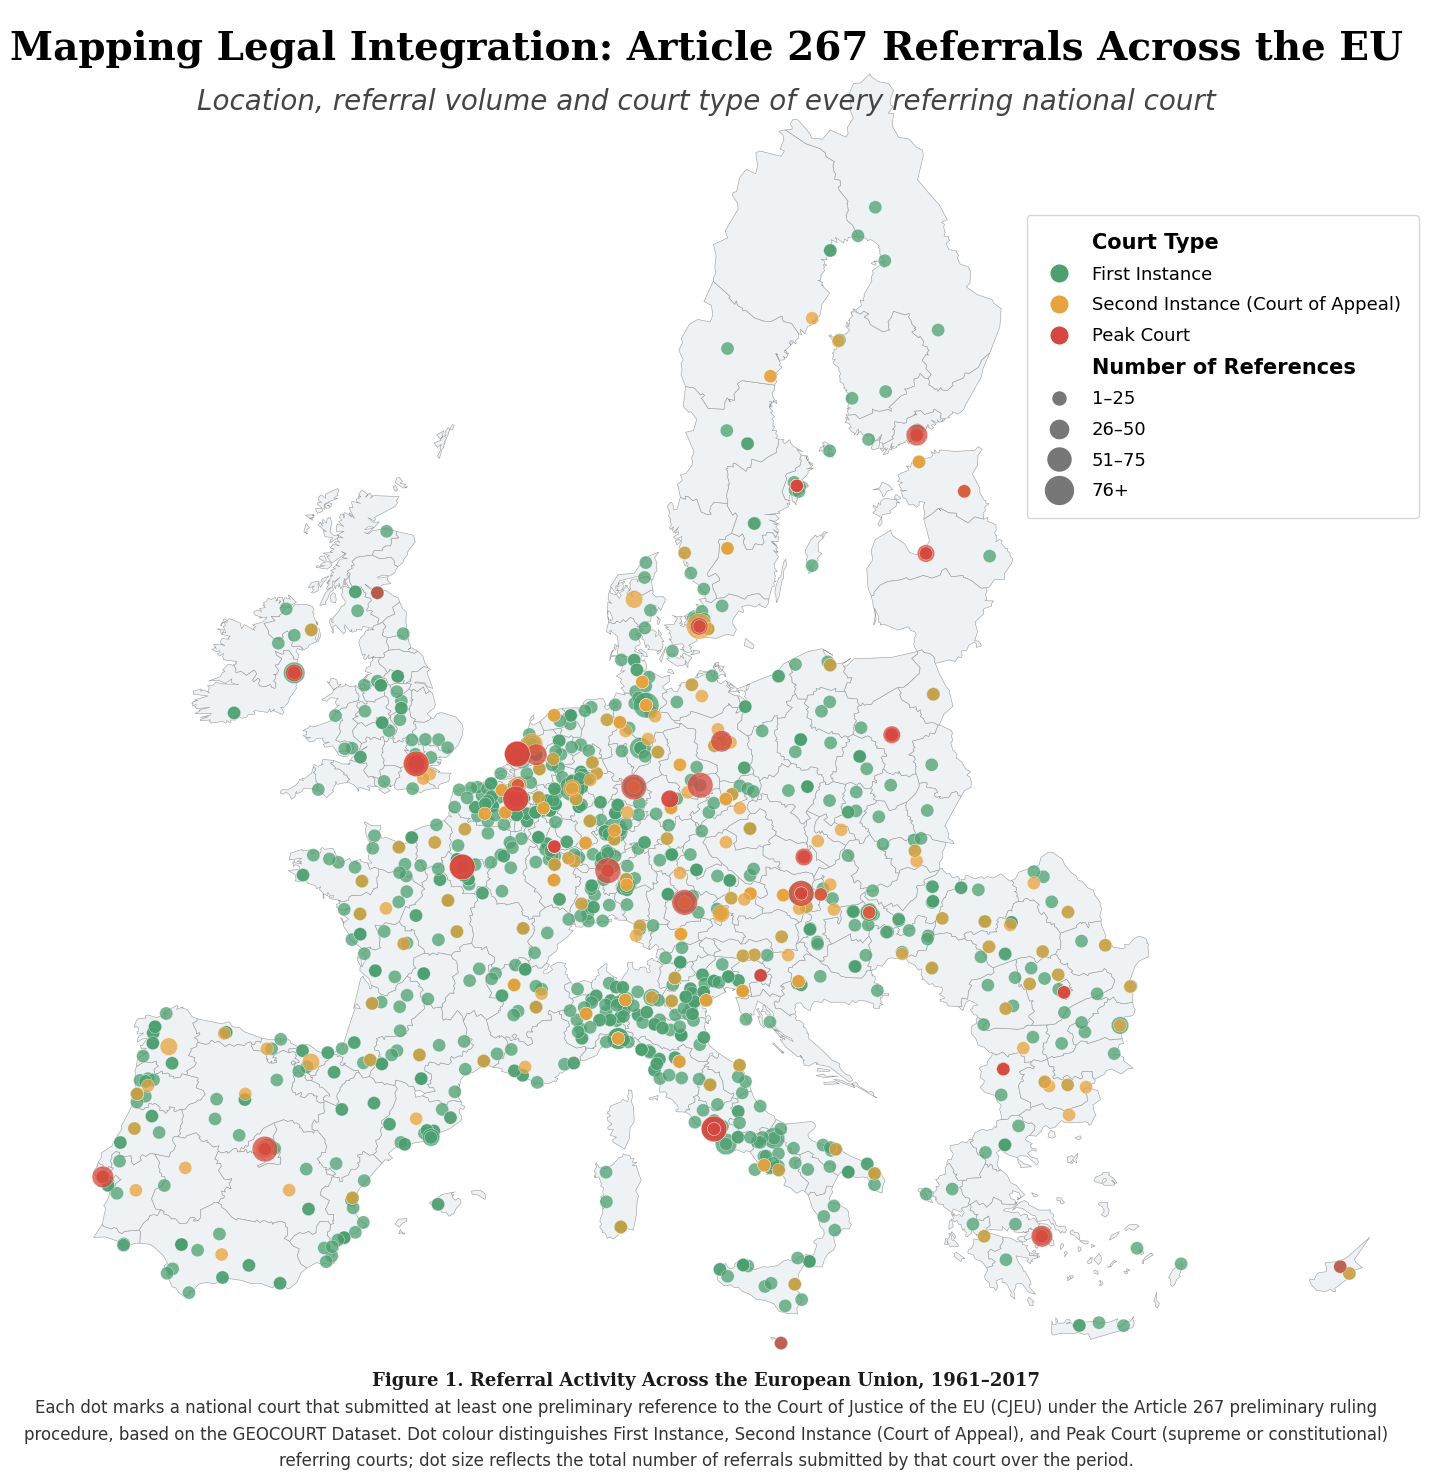

In [19]:
courts_gdf = build_court_geodataframe()

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
plot_courts_on_ax(ax, courts_gdf)

# --- Combined legend: court type + referral tier in one box ---
def _legend_header(text):
    return Line2D([], [], color='none', label=text)

color_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COURT_COLORS[v],
           markersize=14, label=COURT_LABELS[v])
    for v in COURT_TIER_ORDER
]
size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#777777',
           markersize=np.sqrt(SIZE_MAP[lbl]) * 1.2, label=lbl)
    for lbl in FREQ_LABELS
]
combined_handles = (
    [_legend_header('Court Type')] + color_handles +
    [_legend_header('Number of References')] + size_handles
)

legend = ax.legend(
    handles=combined_handles, loc='upper center',
    bbox_to_anchor=(0.85, 0.86), fontsize=13, frameon=True,
    labelspacing=0.7, handletextpad=1.0, borderpad=1.0, handlelength=1.6
)
for txt, h in zip(legend.get_texts(), combined_handles):
    if h.get_label() in ('Court Type', 'Number of References'):
        txt.set_fontweight('bold')
        txt.set_fontsize(15)

# --- Title and caption ---
fig.suptitle(
    'Mapping Legal Integration: Article 267 Referrals Across the EU',
    fontsize=28, fontweight='bold', fontfamily='serif', y=0.89, ha='center'
)
fig.text(0.5, 0.85,
          'Location, referral volume and court type of every referring national court',
          ha='center', fontsize=20, fontstyle='italic', color='#444444')

caption_title = 'Figure 1. Referral Activity Across the European Union, 1961–2017'
caption_body = (
    "Each dot marks a national court that submitted at least one preliminary reference to "
    "the Court of Justice of the EU (CJEU) under the Article 267 preliminary ruling "
    "procedure, based on the GEOCOURT Dataset. Dot colour distinguishes First Instance, Second Instance (Court of Appeal), and Peak Court "
    "(supreme or constitutional) referring courts; dot size reflects the total number "
    "of referrals submitted by that court over the period."
)
caption_body_wrapped = '\n'.join(textwrap.wrap(caption_body, width=165))

fig.text(0.5, 0.21, caption_title, ha='center', va='bottom',
          fontsize=13, fontweight='bold', fontfamily='serif', color='#1a1a1a')
fig.text(0.5, 0.17, caption_body_wrapped, ha='center', va='bottom',
          fontsize=12, color='#333333', linespacing=1.6)

plt.subplots_adjust(top=0.90, bottom=0.20)
plt.savefig('figure1_courts_map.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Figure 2 — Regional Referral Intensity

This figure aggregates referral counts to the NUTS2 level. Two design choices depart from a simple linear colour scale on raw counts:

**Classification, not a linear or log scale.** Regional referral counts are extremely skewed (median around 13 referrals, maximum close to 700 over the full period), so a linear colour scale would compress nearly the entire map into one shade while a handful of outlier regions absorb the rest of the range. Regions are instead classified into six groups using Natural Breaks (Jenks), which finds real gaps in the data rather than imposing equal-width or equal-count bins. The legend reports actual referral counts in each bin, not a transformed value.

**Zero referrals shown as an explicit category, not folded into the colour ramp.** Regions with confirmed zero referrals are plotted as a distinct grey layer, separate from the classified colour ramp for regions with at least one referral. This avoids the lowest activity tier reading as visually indistinguishable from "no data".

**Data source.** Referral counts are aggregated directly from the same court-level file used for Figure 1 (`courts_raw`, full 1961–2017 coverage, 229 regions with at least one referral). An earlier version of this figure used a pre-aggregated covariates file restricted to a 1998–2017 regression sample with complete covariate data; that file covers only 168 regions, so left-joining it onto the full basemap and filling missing values with zero conflated "outside the regression sample" with "confirmed zero referrals" for the 61 regions in between.

In [20]:
# Referral counts aggregated directly from the court-level data already loaded above
referral_by_nuts = courts_raw.groupby('Nuts2').size().reset_index(name='Referral')

merged_gdf = nuts2_gdf.merge(referral_by_nuts, left_on='NUTS_ID', right_on='Nuts2', how='left')
merged_gdf['Referral'] = merged_gdf['Referral'].fillna(0)

zero_gdf = merged_gdf[merged_gdf['Referral'] == 0]
nonzero_gdf = merged_gdf[merged_gdf['Referral'] > 0]

print(f'{len(zero_gdf)} of {len(merged_gdf)} mapped regions have zero referrals over 1961-2017.')

43 of 266 mapped regions have zero referrals over 1961-2017.


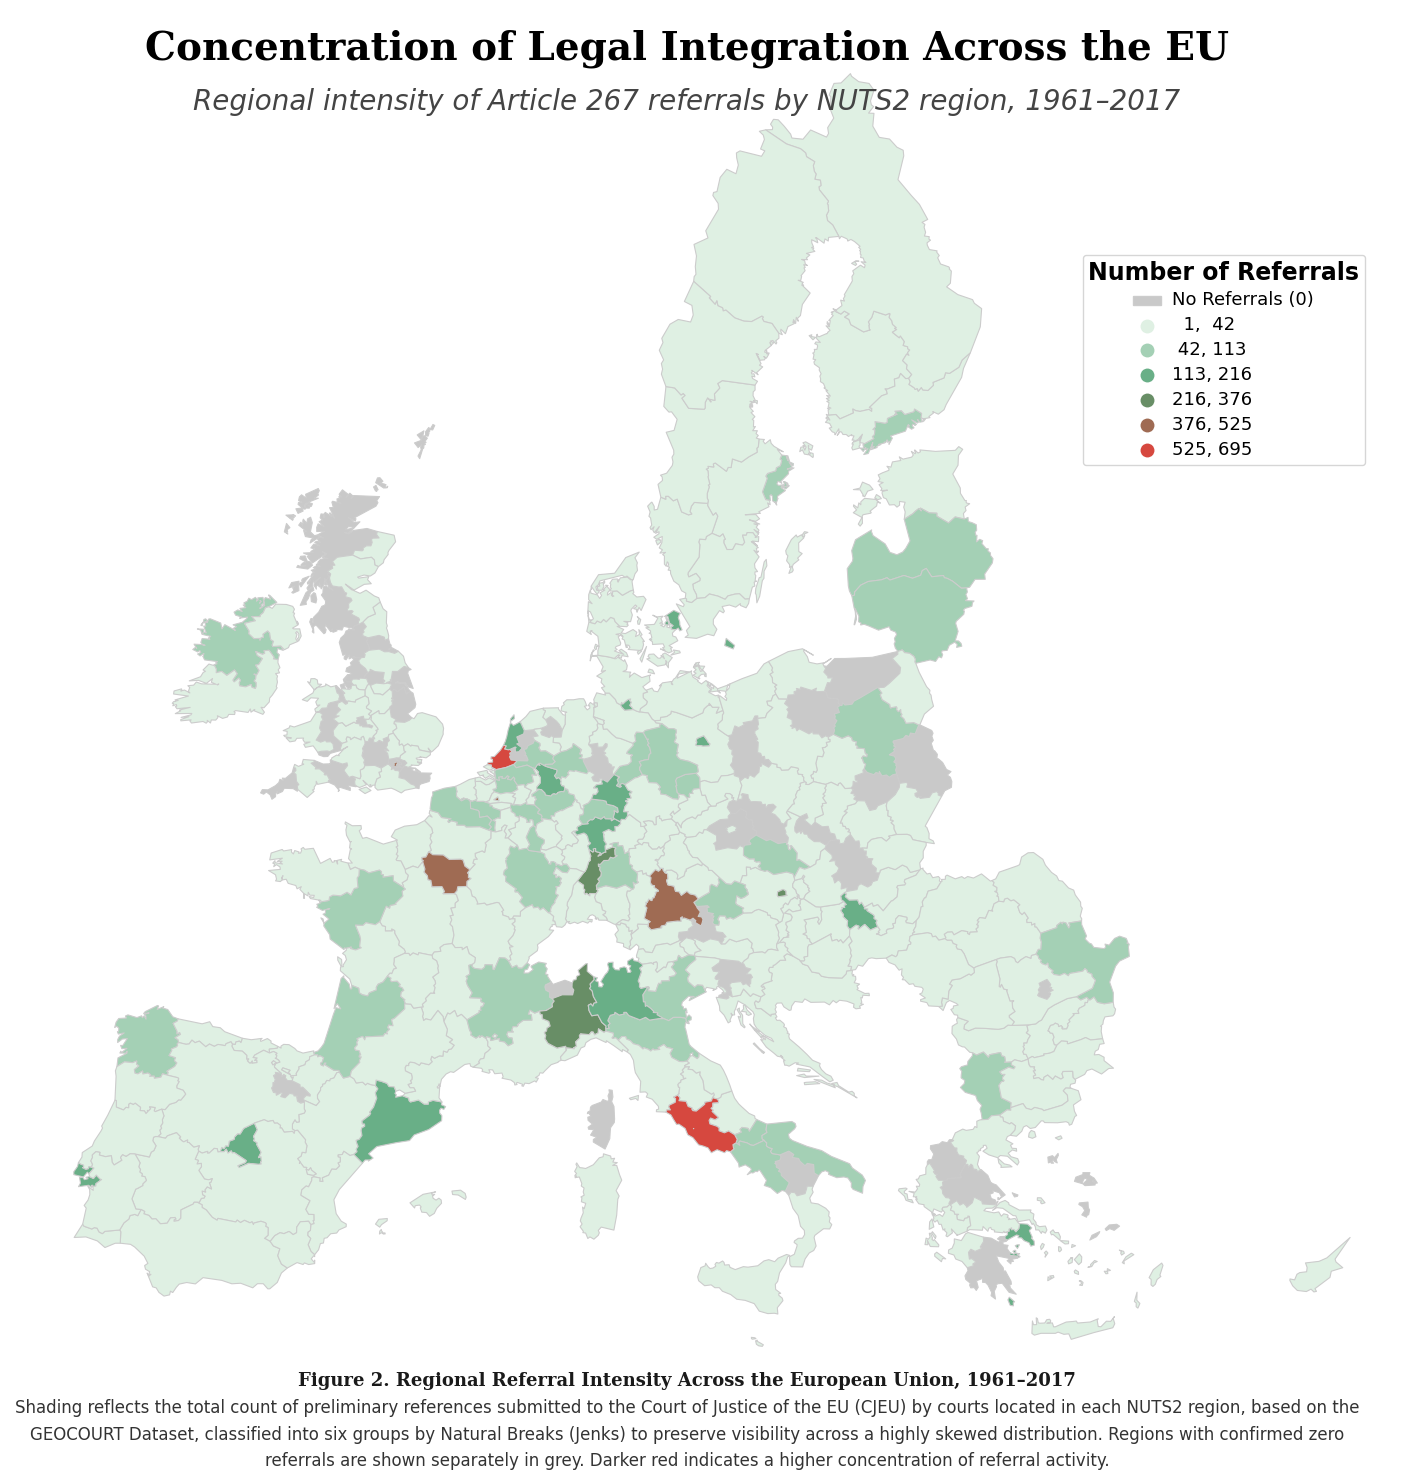

In [21]:
# Colour ramp for regions with at least one referral: starts at a real green (not the
# basemap's light grey/blue), so the lowest activity tier does not read as "no data".
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'geocourt_cmap', ['#DFF0E3', '#4C9F70', '#D6483F']
)

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

zero_gdf.plot(ax=ax, color='#c9c9c9', edgecolor='0.8', linewidth=0.8)

nonzero_gdf.plot(
    column='Referral', scheme='NaturalBreaks', k=6, cmap=custom_cmap,
    linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
    legend_kwds={
        'loc': 'upper right', 'bbox_to_anchor': (0.99, 0.99),
        'title': 'Number of Referrals', 'frameon': False, 'fmt': '{:.0f}',
    }
)

# Fold the zero-referral layer into the same legend box as the classified bins
auto_leg = ax.get_legend()
handles = list(getattr(auto_leg, 'legend_handles', None) or auto_leg.legendHandles)
labels = [t.get_text() for t in auto_leg.get_texts()]
auto_leg.remove()

zero_patch = Patch(facecolor='#c9c9c9', edgecolor='0.8', label='No Referrals (0)')
leg = ax.legend([zero_patch] + handles, ['No Referrals (0)'] + labels,
                 loc='upper right', bbox_to_anchor=(0.97, 0.83),
                 title='Number of Referrals', frameon=True)
leg.get_title().set_fontsize(17)
leg.get_title().set_fontweight('bold')
for txt in leg.get_texts():
    txt.set_fontsize(13)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_axis_off()
ax.set_aspect('equal')

fig.suptitle(
    'Concentration of Legal Integration Across the EU',
    fontsize=28, fontweight='bold', fontfamily='serif', y=0.89, ha='center'
)
fig.text(0.5, 0.85,
          'Regional intensity of Article 267 referrals by NUTS2 region, 1961–2017',
          ha='center', fontsize=20, fontstyle='italic', color='#444444')

caption_title = 'Figure 2. Regional Referral Intensity Across the European Union, 1961–2017'
caption_body = (
    "Shading reflects the total count of preliminary references submitted to the Court of "
    "Justice of the EU (CJEU) by courts located in each NUTS2 region, based on the GEOCOURT "
    "Dataset, classified into six groups by Natural Breaks (Jenks) to preserve visibility "
    "across a highly skewed distribution. Regions with confirmed zero referrals are shown "
    "separately in grey. Darker red indicates a higher concentration of referral activity."
)
caption_body_wrapped = '\n'.join(textwrap.wrap(caption_body, width=165))

fig.text(0.5, 0.21, caption_title, ha='center', va='bottom',
          fontsize=13, fontweight='bold', fontfamily='serif', color='#1a1a1a')
fig.text(0.5, 0.17, caption_body_wrapped, ha='center', va='bottom',
          fontsize=12, color='#333333', linespacing=1.6)

plt.subplots_adjust(top=0.90, bottom=0.20)
plt.savefig('figure2_referral_choropleth.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Figure A2 — Referral Activity by Period

Figure 1 is broken down into three sub-periods, matching the paper's own periodised appendix figure.

Dot size is recomputed **within each panel** from referrals in that period only — a court's dot in the 1961–1985 panel reflects its activity during that 25-year window, not its lifetime total. The four size-tier breaks (25/50/75/100+) are kept fixed and identical across all three panels so that dot sizes remain directly comparable across panels: a "76+" court in the first panel is genuinely as active in that window as a "76+" court in the last one. Earlier panels skew toward the smaller tiers simply because there is less time for referrals to accumulate, a substantive finding the paper itself discusses (referral activity accelerating over the sample period), not an artefact of the binning choice.

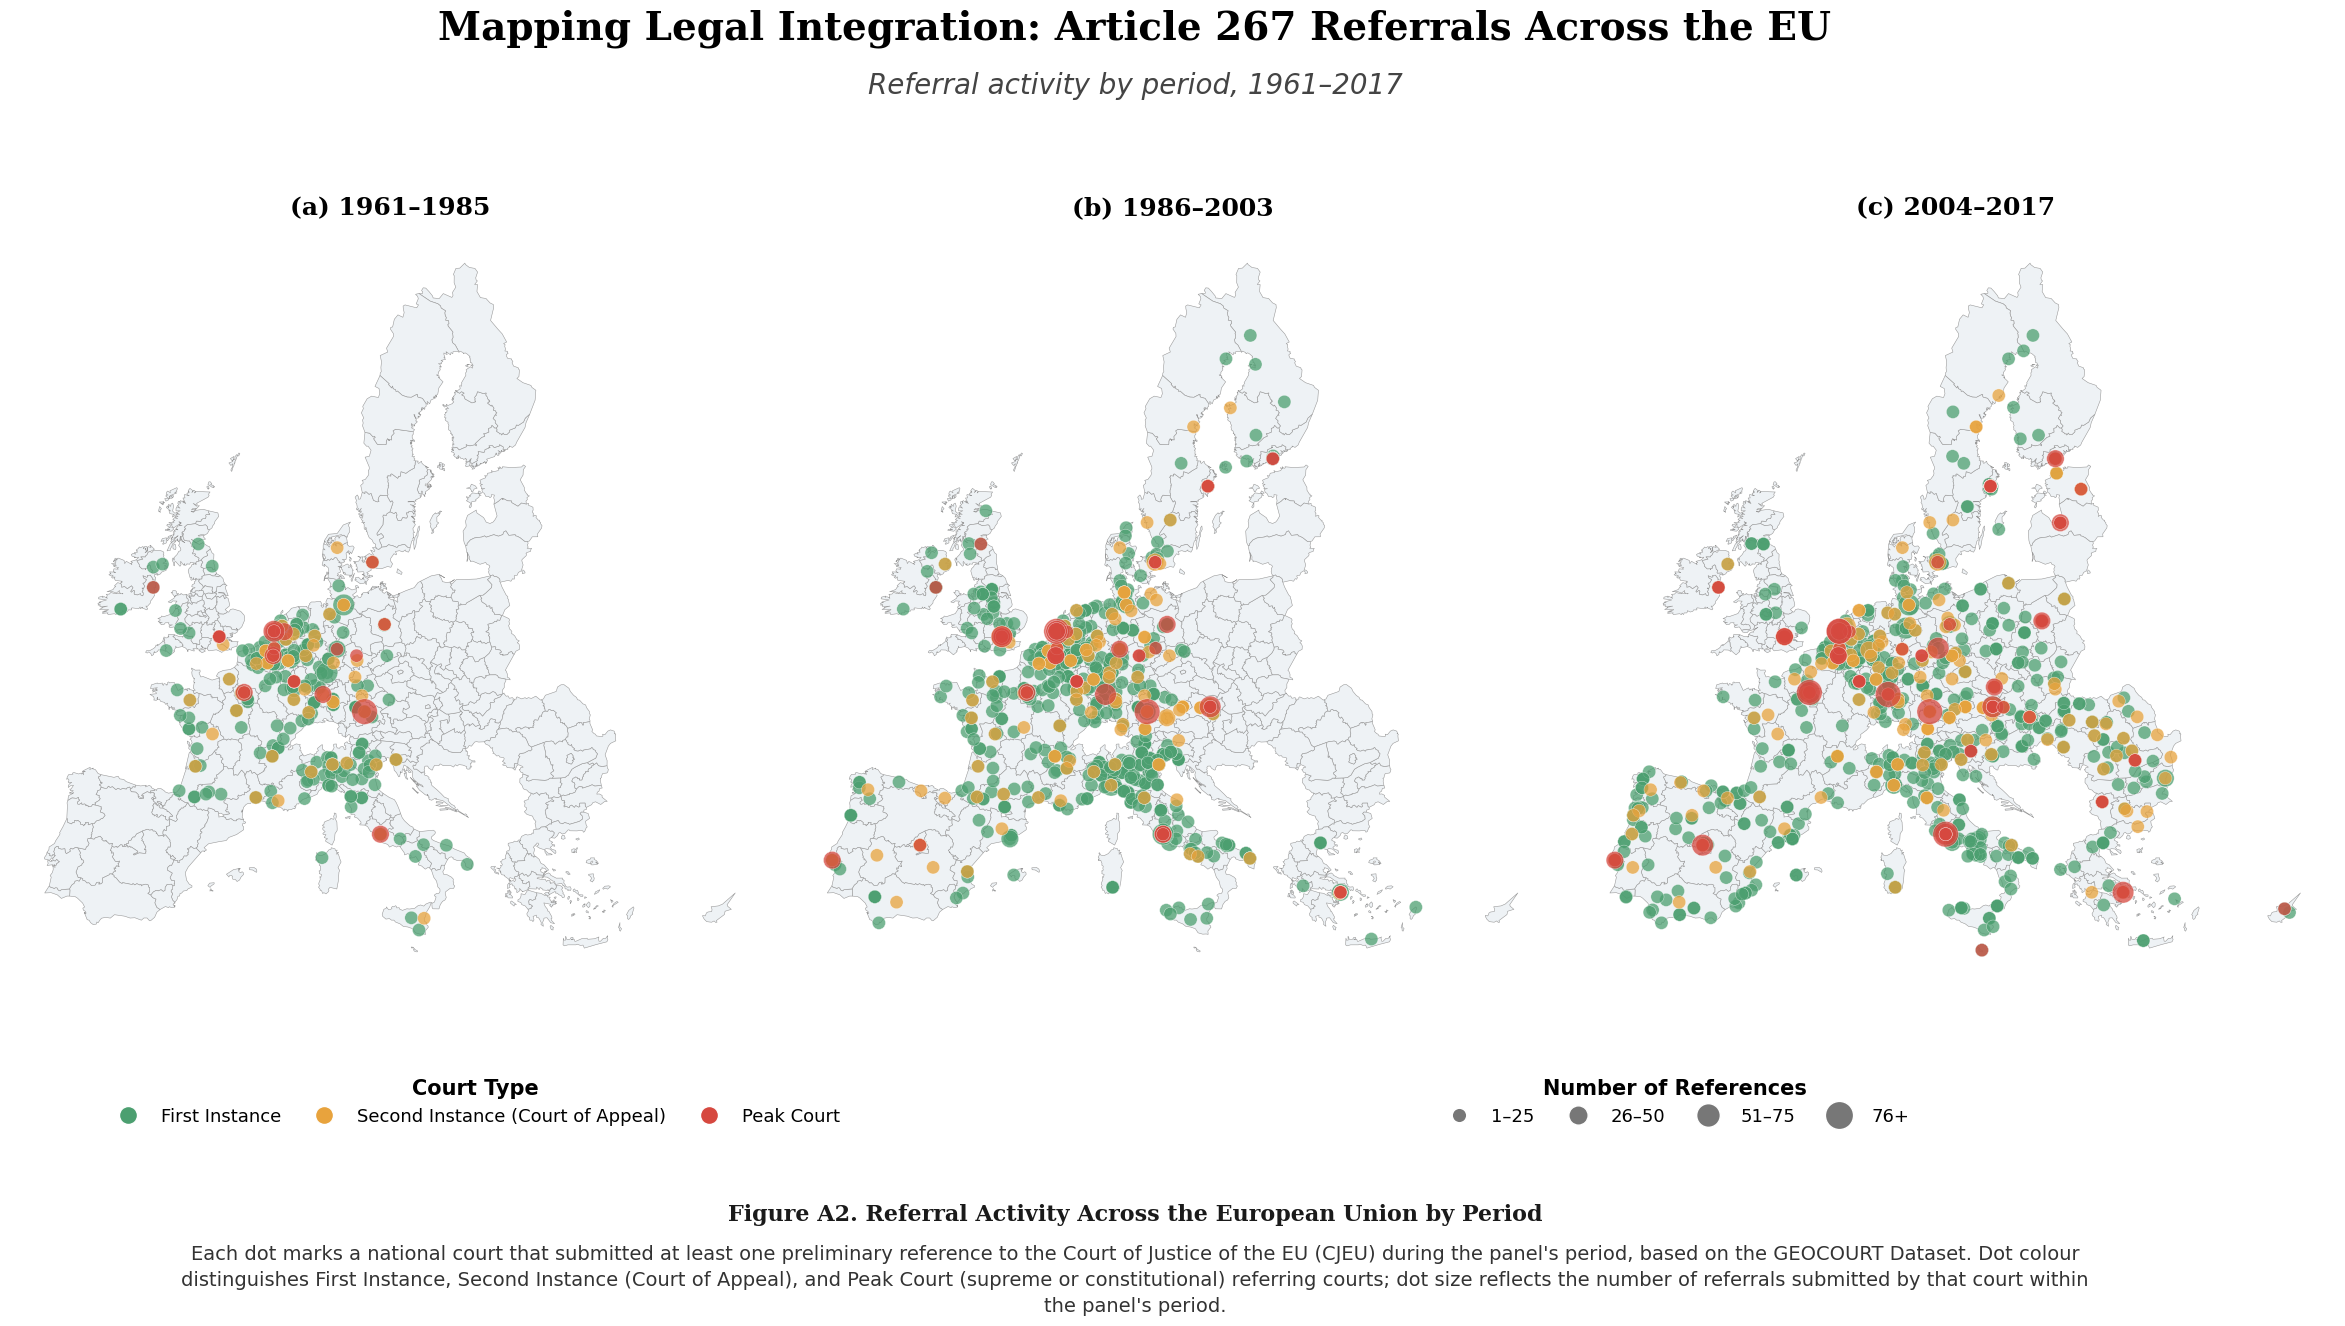

In [24]:
periods = [
    (1961, 1985, '(a) 1961–1985'),
    (1986, 2003, '(b) 1986–2003'),
    (2004, 2017, '(c) 2004–2017'),
]

fig, axes = plt.subplots(1, 3, figsize=(30, 13))

for ax, (y0, y1, subtitle) in zip(axes, periods):
    panel_gdf = build_court_geodataframe(y0, y1)
    plot_courts_on_ax(ax, panel_gdf, subtitle=subtitle)

# --- Legend split into two horizontal groups, placed below the maps ---
color_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COURT_COLORS[v],
           markersize=13, label=COURT_LABELS[v])
    for v in COURT_TIER_ORDER
]
size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#777777',
           markersize=np.sqrt(SIZE_MAP[lbl]) * 1.1, label=lbl)
    for lbl in FREQ_LABELS
]

legend1 = fig.legend(
    handles=color_handles, labels=[h.get_label() for h in color_handles],
    loc='upper center', bbox_to_anchor=(0.28, 0.2), ncol=3,
    fontsize=13, frameon=False, title='Court Type', title_fontsize=15,
    columnspacing=1.4, handletextpad=0.8
)
legend1.get_title().set_fontweight('bold')

legend2 = fig.legend(
    handles=size_handles, labels=[h.get_label() for h in size_handles],
    loc='upper center', bbox_to_anchor=(0.68, 0.2), ncol=4,
    fontsize=13, frameon=False, title='Number of References', title_fontsize=15,
    columnspacing=1.4, handletextpad=0.8
)
legend2.get_title().set_fontweight('bold')

# --- Title and caption ---
fig.suptitle(
    'Mapping Legal Integration: Article 267 Referrals Across the EU',
    fontsize=28, fontweight='bold', fontfamily='serif', y=1.01, ha='center'
)
fig.text(0.5, 0.945,
          'Referral activity by period, 1961–2017',
          ha='center', fontsize=20, fontstyle='italic', color='#444444')

caption_title = 'Figure A2. Referral Activity Across the European Union by Period'
caption_body = (
    "Each dot marks a national court that submitted at least one preliminary reference to "
    "the Court of Justice of the EU (CJEU) during the panel's period, based on the GEOCOURT "
    "Dataset. Dot colour distinguishes First Instance, Second Instance (Court of Appeal), and Peak Court "
    "(supreme or constitutional) referring courts; dot size reflects the number of referrals submitted by that court "
    "within the panel's period."
)
caption_body_wrapped = '\n'.join(textwrap.wrap(caption_body, width=200))

fig.text(0.5, 0.075, caption_title, ha='center', va='bottom',
          fontsize=16, fontweight='bold', fontfamily='serif', color='#1a1a1a')
fig.text(0.5, 0.005, caption_body_wrapped, ha='center', va='bottom',
          fontsize=14, color='#333333', linespacing=1.5)

plt.subplots_adjust(top=0.90, bottom=0.20, wspace=0.03)
plt.savefig('figureA2_courts_by_period.png', dpi=300, bbox_inches='tight')
plt.show()